In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

Device: cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [9]:
DATASET_PATH = "/kaggle/input/datasets/hal0samuel/pikachu-classification-dataset/pikachu_dataset"

In [10]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=test_transform
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['not_pikachu', 'pikachu']
Number of classes: 2


In [46]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [36]:
#resnet - 50 rough
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):

        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):

        downsample = None

        if stride != 1 or self.in_channels != out_channels * block.expansion:

            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels,
                          out_channels * block.expansion,
                          kernel_size=1,
                          stride=stride,
                          bias=False),
                nn.BatchNorm2d(out_channels * block.expansion)
            )

        layers = []

        layers.append(block(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x



def ResNet50(num_classes):

    return ResNet(Bottleneck, [3,4,6,3], num_classes)


In [42]:
model = ResNet50(num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [38]:
scaler = torch.amp.GradScaler('cuda')

In [47]:
EPOCHS = 50

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    scheduler.step()

    print(f"Epoch {epoch+1} Loss:", running_loss/len(train_loader))

  0%|          | 0/25 [00:00<?, ?it/s]/tmp/ipykernel_55/2361167219.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch [1/50]: 100%|██████████| 25/25 [00:04<00:00,  5.31it/s, loss=0.623]


Epoch 1 Loss: 0.26600550174713133


Epoch [2/50]: 100%|██████████| 25/25 [00:04<00:00,  5.44it/s, loss=0.222]


Epoch 2 Loss: 0.2643135917186737


Epoch [3/50]: 100%|██████████| 25/25 [00:04<00:00,  5.14it/s, loss=0.286]


...

Epoch 48 Loss: 0.14350871056318282


Epoch [49/50]: 100%|██████████| 25/25 [00:04<00:00,  5.44it/s, loss=0.177] 


Epoch 49 Loss: 0.1865024036169052


Epoch [50/50]: 100%|██████████| 25/25 [00:05<00:00,  4.99it/s, loss=0.0745]

Epoch 50 Loss: 0.13797441020607948


In [45]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation accuracy:", correct/total)

Validation accuracy: 0.8682170542635659


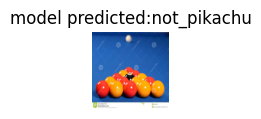

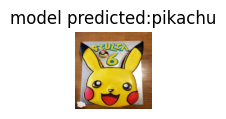

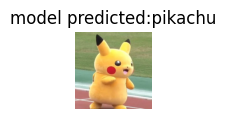

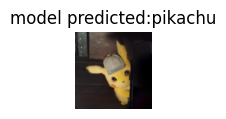

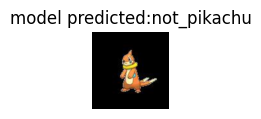

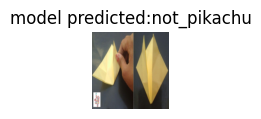

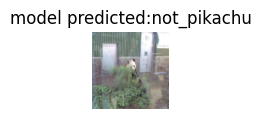

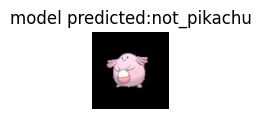

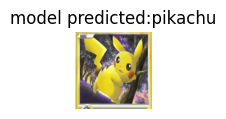

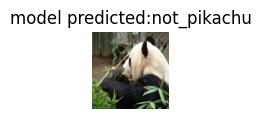

In [35]:
import random
import matplotlib.pyplot as plt

model.eval()

num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)

for idx in indices:

    img, label = test_dataset[idx]

    img_gpu = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_gpu).argmax(1).item()

    true_label = class_names[label]
    pred_label = class_names[pred]

    img_show = img.permute(1,2,0)

    plt.figure(figsize=(1,1))
    plt.imshow(img_show)
    plt.title(f"model predicted:{pred_label}")
    plt.axis("off")
    plt.show()